In [1]:
import hoda
import tensorly as tl
import mne

!pip install line_profiler
%load_ext line_profiler
mne.set_log_level('ERROR')
tl.get_backend()


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
4195,1,0,0
4196,1,0,0
4197,1,0,0
4198,1,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 48)

In [6]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings

bttda = GreedyBTTDA(
    max_blocks=10,
    truncate=True,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='eye',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=False,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=False,
    cv=StratifiedKFold(random_state=42, shuffle=True),
    n_jobs=2,
    
)
%env PYTHONWARNINGS=ignore
%prun bttda.fit(X,y)

env: PYTHONWARNINGS=ignore
Model selection block 1/10...
Model selection block 2/10...
Model selection block 3/10...
Model selection block 4/10...
Model selection block 5/10...
Model selection block 6/10...
Model selection block 7/10...
Model selection block 8/10...
Model selection block 9/10...
Model selection block 10/10...
Fitting block 1/3...
Fitting block 2/3...
Fitting block 3/3...
 

         420095 function calls (401909 primitive calls) in 84.126 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     7433   79.625    0.011   79.625    0.011 {built-in method time.sleep}
       53    1.855    0.035    3.050    0.058 hoda.py:340(fit_forward)
      200    0.349    0.002    0.349    0.002 {built-in method cupy_backends.cuda.libs.cusolver.xsyevd}
        2    0.185    0.093    0.185    0.093 {built-in method cupy_backends.cuda.libs.nvrtc.compileProgram}
     1040    0.166    0.000    0.527    0.001 cov.py:17(mode_scatter)
     1868    0.163    0.000    0.164    0.000 {built-in method cupy._core._routines_linalg.tensordot_core}
     1756    0.144    0.000    0.214    0.000 core.py:689(norm)
      814    0.121    0.000    0.121    0.000 {built-in method cupy._core.core.array}
     2458    0.101    0.000    0.102    0.000 {method 'dot' of 'cupy._core.core._ndarray_base' objects}
     2386    0.083    0.000    0.

In [7]:
import pandas as pd
df = pd.DataFrame(bttda.model_select_info_)
df

,block,fold,rank,hoda,train_score,val_score
0,0,0,1,"HODA(init='eye', max_iter=128, random_state=42...",0.827420,0.813378
1,0,0,2,"HODA(init='eye', max_iter=128, random_state=42...",0.844730,0.827051
2,0,0,4,"HODA(init='eye', max_iter=128, random_state=42...",0.863446,0.835184
3,0,0,8,"HODA(init='eye', max_iter=128, random_state=42...",0.880619,0.857939
4,0,1,1,"HODA(init='eye', max_iter=128, random_state=42...",0.821098,0.842541
...,...,...,...,...,...,...
195,9,3,8,"HODA(init='eye', max_iter=128, random_state=42...",0.899099,0.829480
196,9,4,1,"HODA(init='eye', max_iter=128, random_state=42...",0.895247,0.840582
197,9,4,2,"HODA(init='eye', max_iter=128, random_state=42...",0.896452,0.840888
198,9,4,4,"HODA(init='eye', max_iter=128, random_state=42...",0.898271,0.838786


In [8]:
df_max= df.groupby(['block', 'rank'])
df_max = df_max.aggregate('mean')
df_max=df_max.reset_index()
df_max = df_max.iloc[df_max.groupby('block')['val_score'].idxmax()]
df_max

/tmp/ipykernel_5207/3558220141.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_max = df_max.aggregate('mean')


,block,rank,fold,train_score,val_score
3,0,8,2.0,0.884641,0.835988
5,1,2,2.0,0.889500,0.839933
9,2,2,2.0,0.891052,0.840678
12,3,1,2.0,0.891886,0.839965
17,4,2,2.0,0.893328,0.840112
21,5,2,2.0,0.893735,0.839947
24,6,1,2.0,0.893779,0.839576
28,7,1,2.0,0.893982,0.839598
33,8,2,2.0,0.894272,0.839237
36,9,1,2.0,0.894397,0.839043


In [9]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank
0,1,"(8, 8)"
1,2,"(2, 2)"
2,3,"(2, 2)"


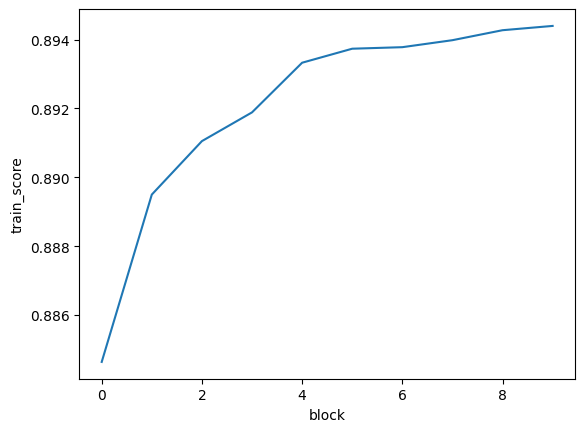

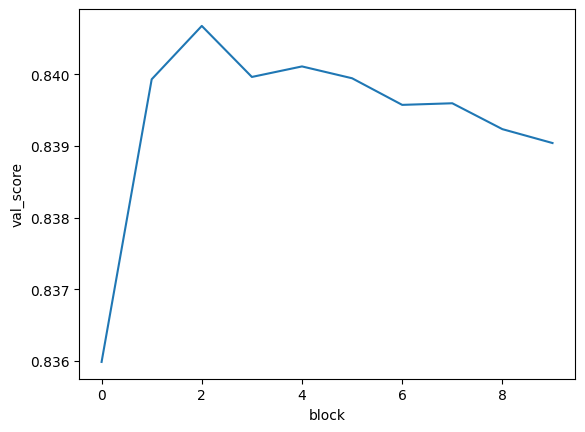

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
n_samples = X.shape[0]
sns.lineplot(data=df_max, x='block', y='train_score')
plt.show()
sns.lineplot(data=df_max, x='block', y='val_score')

#sns.lineplot(data=df, x='block', y='test_score')
plt.show()

In [11]:
Xt = bttda.transform(X)

In [12]:
bttda.n_blocks_

3

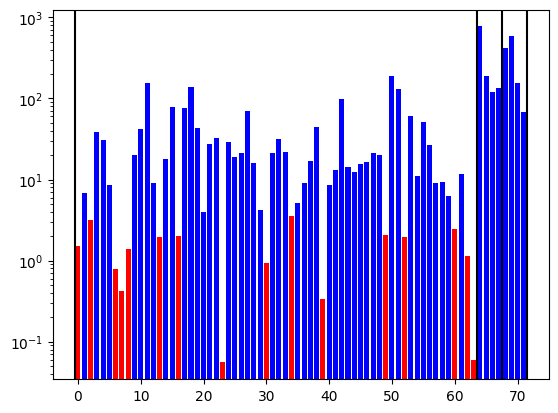

In [13]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < 0.05
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b,block in enumerate(bttda.blocks_):
    n_params+=math.prod(block.rank_)
    plt.axvline(n_params-.5, color='black')

      index       PC1       PC2      label
0         0 -1.128738  1.985001  NonTarget
1         1  1.855922 -1.322637  NonTarget
2         2 -0.644518  0.726891  NonTarget
3         3 -0.899243  1.807411  NonTarget
4         4 -0.069912 -1.460256  NonTarget
...     ...       ...       ...        ...
4195   4195  0.409463 -1.804539  NonTarget
4196   4196  0.652845  0.884002     Target
4197   4197 -0.807310  1.465847  NonTarget
4198   4198  0.233672  0.263470  NonTarget
4199   4199 -0.916776 -1.465254  NonTarget

[4200 rows x 4 columns]


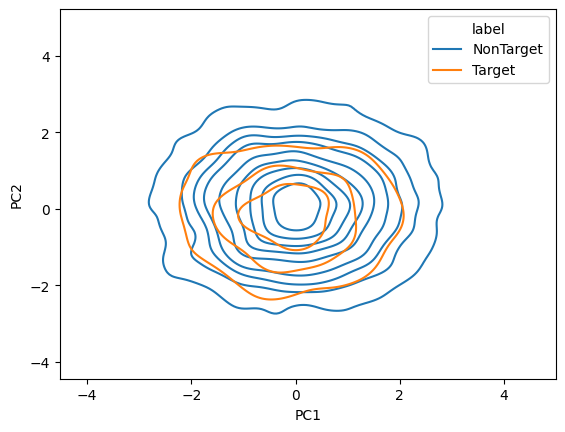

In [14]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    #sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)

In [15]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]), units=dict(eeg=None))
joint_args=dict(ts_args=ts_args)

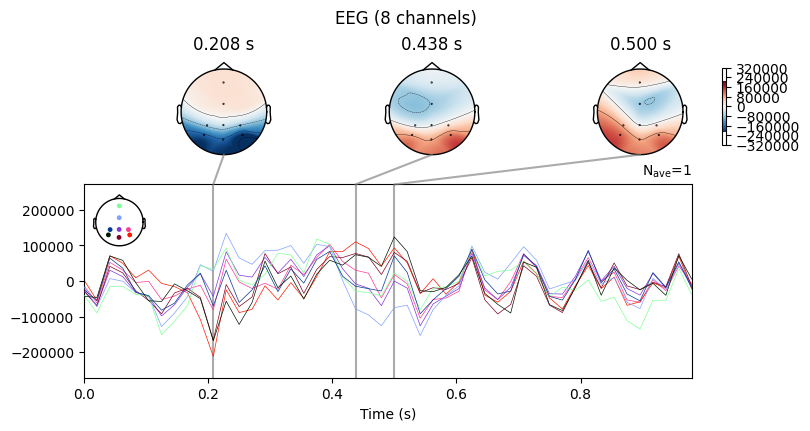

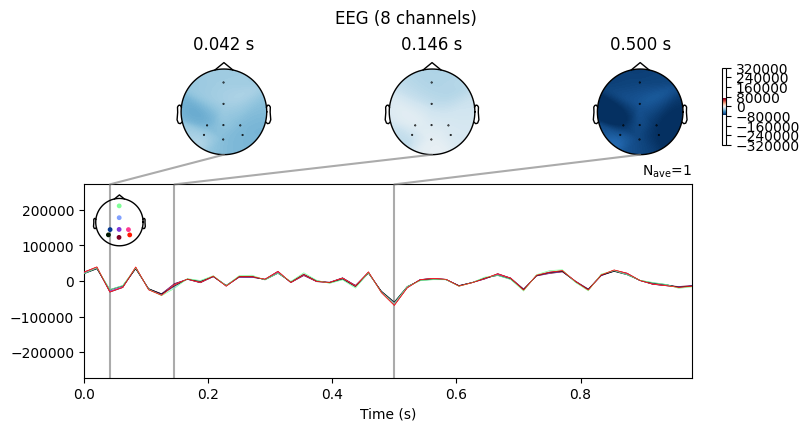

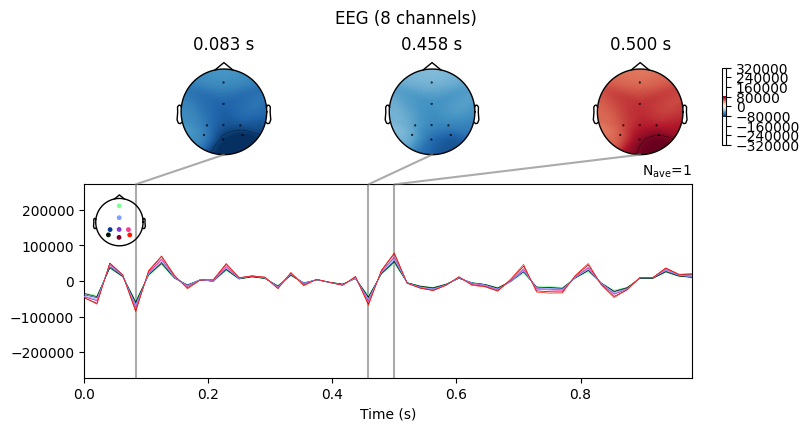

In [16]:
from mne import EvokedArray
for b in bttda.blocks_[:10]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

In [17]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    #if len(evoked_rec.ch_names) > 1:
    #    evoked_rec.plot_joint(title=cls,**joint_args)
    #else:
    #    evoked_rec.plot(**ts_args)

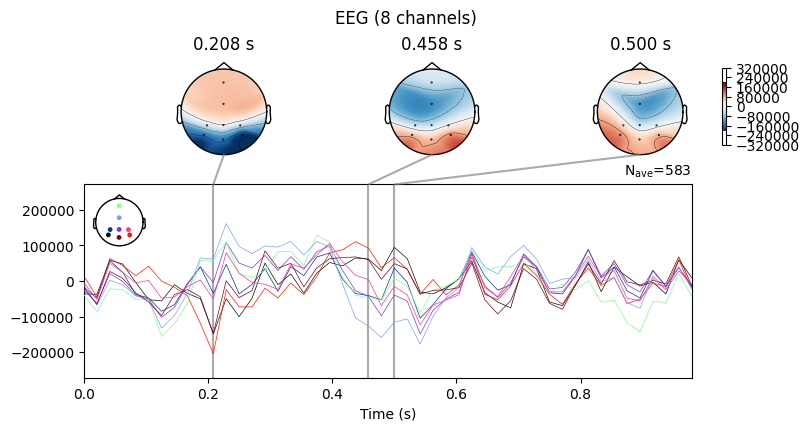

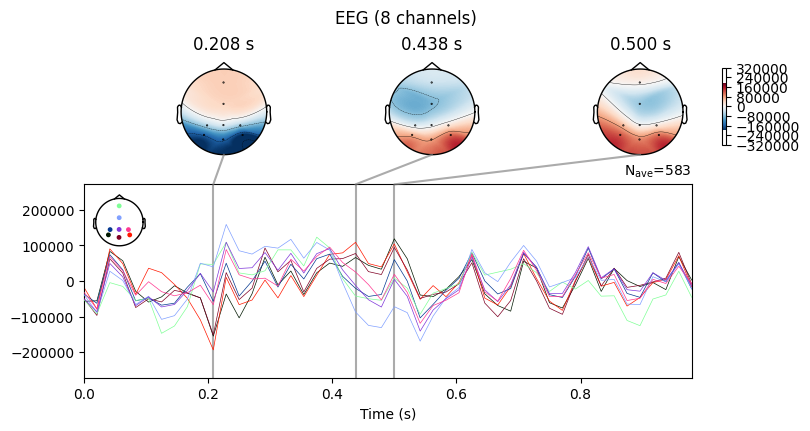

In [18]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


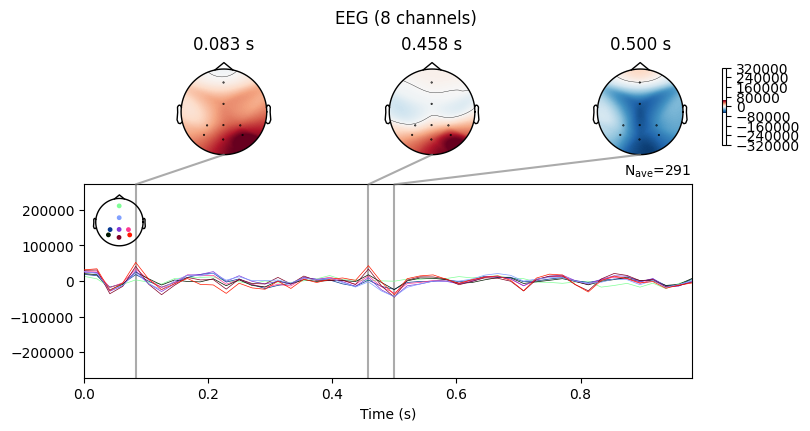

In [19]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)